In [1]:
from langchain_openai import ChatOpenAI

# 모델 초기화
model=ChatOpenAI(model="gpt-4o", temperature=0.01)
model.invoke('안녕하세요!')

AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 10, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f33640a400', 'id': 'chatcmpl-CHzv3lXPwddsxiyvx4VjxJ9Pat9r9', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--eef79d84-c5ee-47e0-aebf-7c871e174e3d-0', usage_metadata={'input_tokens': 10, 'output_tokens': 10, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [2]:
from typing import Annotated    # annotated는 타입 힌트를 사용할 때 사용하는 점수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages(Annoted[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.
        'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
    """
    messages: Annotated[list[str], add_messages]

# StateGraph 클래스를 사용하여 State 타입의 그래프 생성
graph_builder=StateGraph(State)

In [3]:
from langchain_core.tools import tool
from datetime import datetime
import pytz

from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

import bs4
from langchain_community.document_loaders import WebBaseLoader


# 도구 함수 정의
@tool
def get_current_time(timezone: str, location: str) -> str:
    """ 현재 시각을 반환하는 함수. """
    try:
        tz=pytz.timezone(timezone)
        now=datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재 시각 {now}'
        # print(result)
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"
    
@tool
def get_web_search(query:str, search_period:str='m')->str:

    """
    웹 검색을 수행하는 함수

    Args:
        query (str) : 검색어
        search_period (str) : 검색 기간 (e.g., "w" for past week, "m" for past month, "y" for past year)

    Returns:
        str: 검색 결과
    """
    wrapper=DuckDuckGoSearchAPIWrapper(
        # region="kr-kr",
        time=search_period)
    
    print('-----------WEB SEARCH------------')
    print(query)
    print(search_period)

    search=DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        # source="news",
        results_separator=';\n'
    )

    searched=search.invoke(query)

    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')

    return searched

# 도구 바인딩
tools=[get_current_time, get_web_search]

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
tools[0].invoke({"timezone":"Asia/Seoul", "location":"서울"})

'Asia/Seoul (서울) 현재 시각 2025-09-21 07:12:21'

In [6]:
tools[1].invoke({"query":"파이썬", "search_period":"m"})

-----------WEB SEARCH------------
파이썬
m
1. snippet: 1 week ago - 파이썬 (영어: Python)은 1991년 네덜란드계 소프트웨어 엔지니어인 귀도 반 로섬이 발표한 고급 프로그래밍 언어로, '인터프리터를 사용하는 객체지향 언어'이자 플랫폼에 독립적인, 동적 타이핑(dynamically typed) 대화형 언어다., title: Wikipedia 파이썬 - 위키백과, 우리 모두의 백과사전, link: https://ko.wikipedia.org/wiki/파이썬
2. snippet: 4 hours ago - Python is a high-level, general-purpose programming language. Its design philosophy emphasizes code readability with the use of significant indentation. Python is dynamically type-checked and garbage-collected. It supports multiple programming paradigms, including structured (particularly ..., title: Wikipedia Python (programming language) - Wikipedia, link: https://en.wikipedia.org/wiki/Python_(programming_language)
3. snippet: 3 weeks ago - Look up Python or python in Wiktionary, the free dictionary. ... Python (painter) (ca. 360–320 BCE), vase painter in Poseidonia · Python of Byzantium (4th-century BCE), orator, diplomat of Philip II of Macedon · Python of Catana, poet who a

"snippet: 1 week ago - 파이썬 (영어: Python)은 1991년 네덜란드계 소프트웨어 엔지니어인 귀도 반 로섬이 발표한 고급 프로그래밍 언어로, '인터프리터를 사용하는 객체지향 언어'이자 플랫폼에 독립적인, 동적 타이핑(dynamically typed) 대화형 언어다., title: Wikipedia 파이썬 - 위키백과, 우리 모두의 백과사전, link: https://ko.wikipedia.org/wiki/파이썬;\nsnippet: 4 hours ago - Python is a high-level, general-purpose programming language. Its design philosophy emphasizes code readability with the use of significant indentation. Python is dynamically type-checked and garbage-collected. It supports multiple programming paradigms, including structured (particularly ..., title: Wikipedia Python (programming language) - Wikipedia, link: https://en.wikipedia.org/wiki/Python_(programming_language);\nsnippet: 3 weeks ago - Look up Python or python in Wiktionary, the free dictionary. ... Python (painter) (ca. 360–320 BCE), vase painter in Poseidonia · Python of Byzantium (4th-century BCE), orator, diplomat of Philip II of Macedon · Python of Catana, poet who accompanied Alexander the Great · Python Angh

In [7]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x0000023E0BC72480>
get_web_search name='get_web_search' description='웹 검색을 수행하는 함수\n\nArgs:\n    query (str) : 검색어\n    search_period (str) : 검색 기간 (e.g., "w" for past week, "m" for past month, "y" for past year)\n\nReturns:\n    str: 검색 결과' args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x0000023E0BE86340>


In [8]:
model_with_tools=model.bind_tools(tools) # GPT 언어모델에 도구 연결

def generate(state:State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.

    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리.
        형식은 {"messages": [응답 메시지]}입니다.
    """

    return {"messages": [model_with_tools.invoke(state["messages"])]}

graph_builder.add_node("generate", generate)

In [10]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
    Attributes:
        tools_by_name (dict): 도구 이름을 키로 하고 도구 객체를 값으로 가지는 사전입니다.
    Methods:
        __init__(tools: list): 도구 객체들의 리스트를 받아서 초기화합니다.
        __call__(input: dict): 입력 메시지를 받아서 도구를 실행하고 결과 메시지를 반환합니다.
    """
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:
        self.tools_by_name={tool.name: tool for tool in tools}
    
    def __call__(self, inputs:dict):
        if messages:=inputs.get("messages",[]):
            # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트 가져오기
            message=messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs=[]
        for tool_call in message.tool_calls:
            tool_result=self.tools_by_name[tool_call["name"]].invoke(tool_call["args"])
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": messages + outputs}
    
tool_node=BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [12]:
def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 끝으로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state,list):
        ai_message=state[-1]
    elif messages:=state.get("messages",[]):
        ai_message=messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
    if hasattr(ai_message,"tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

graph_builder.add_edge(START,"generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools":"tools", END:END}
)

# 도구가 호출될 때마다 다음 단계를 결정하기 위해 챗봇으로 돌아감
graph_builder.add_edge("tools","generate")
graph = graph_builder.compile()

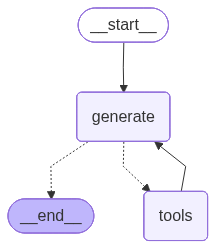

In [13]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [14]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs=[HumanMessage(content="지금 서울 몇 시야?")]

gathered=None

for msg, metadata in graph.stream({"messages":inputs},stream_mode="messages"):
    if isinstance(msg,AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered=msg
        else:
            gathered = gathered + msg

gathered

지금 서울은 2025년 9월 21일 오전 8시 1분입니다.

AIMessageChunk(content='지금 서울은 2025년 9월 21일 오전 8시 1분입니다.', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_Ozro4TAqI1ihJO9W7pE12LiE', 'function': {'arguments': '{"timezone":"Asia/Seoul","location":"서울"}', 'name': 'get_current_time'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_callsstop', 'model_name': 'gpt-4o-2024-08-06gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f33640a400fp_f33640a400', 'service_tier': 'defaultdefault'}, id='run--9e2ba701-2c06-40ff-85b1-e02e807bd2d4', tool_calls=[{'name': 'get_current_time', 'args': {'timezone': 'Asia/Seoul', 'location': '서울'}, 'id': 'call_Ozro4TAqI1ihJO9W7pE12LiE', 'type': 'tool_call'}], tool_call_chunks=[{'name': 'get_current_time', 'args': '{"timezone":"Asia/Seoul","location":"서울"}', 'id': 'call_Ozro4TAqI1ihJO9W7pE12LiE', 'index': 0, 'type': 'tool_call_chunk'}])

In [ ]:
from langchain_core.messages import AIMessageChunk, SystemMessage

about="서울 월드컵 경기장 잔디 문제"

inputs = [SystemMessage(content=f"""
너는 신문기자이다.
최근 {about}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.

- 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘.
- 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐.
- 검색할 리스트를 토대로 재검색해.
- 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해.
- 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋아.

더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성한다.
제목, 부제, 리드문, 본문의 구성으로 작성한다. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다.
""")]

for msg, metadata in graph.stream({"messages":inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

-----------WEB SEARCH------------
서울 월드컵 경기장 잔디 문제
w
1. snippet: 서울월드컵경기장은 대한민국 서울특별시에 있는 스포츠 시설이다. 2002년 FIFA 월드컵 개최를 위해 건설되었으며, 삼성엔지니어링에서 시공하였다. 총 좌석수는 2014년 2월 테이블석을 설치하면서 기존 66,806석에서 102석이 줄어들어 66,704석이 되었으며 귀빈석 816석, 보도석 754석..., title: 서울월드컵경기장 - 위키백과, 우리 모두의 백과사전, link: https://ko.wikipedia.org/wiki/서울월드컵경기장
2. snippet: 경기장 주변에는 경기장 북쪽으로 연결되는 월드컵경기장역 2번 출구에는 GS25가 있고, 2016년부터 개장한 FC 서울 팬파크가 있다., title: 서울월드컵경기장 - 나무위키, link: https://namu.wiki/w/서울월드컵경기장
3. snippet: 서울 월드컵 경기장 은 서측 하단 관람석의 제일 윗부분에 VIP석이 있다. 서울 월드컵 경기장은 경기장 중앙의 링트러스에 2kW의 용량을 가진 메탈할라이드 전등 을 264개 설치하였다., title: bolog.com/books/월드컵경기장과학탐방_지도자료.pdf, link: https://bolog.com/books/월드컵경기장과학탐방_지도자료.pdf
4. snippet: 경기장 잔디가 원상복귀 될 때까지 서울시설공단은 졸속행정이 아닌 매뉴얼대로 적법한 행정절차가 이뤄질 수 있도록 최선을 다해야 할 것이라고 덧붙였다. /정종오 기자(ikokid@inews24.com)., title: 잼버리로 망가진 11억 서울월드컵경기장 잔디 …복구비용은?, link: https://v.daum.net/v/20230912102813144
최근 서울 월드컵 경기장의 잔디 문제가 주목받고 있습니다. 특히, 잔디의 상태가 경기의 질에 영향을 미치고 있으며, 이에 대한 관리 및 복구 비용이 상당하다는 점이 이슈가 되고 있습니다. 이 주제는 많

: 